# SoC control with Robust MPC
This notebook demonstrates how Model Predictive Control (MPC) performance is influenced by system disturbances and how robust approaches, such as tube-based MPC, can effectively mitigate these effects.  

A simple linear energy storage model is considered.

**Key features:**

* **Decision variables**: charge/discharge powers over the horizon. 
* **Objective function:** track the SoC reference (stage and terminal terms) and penalize input rate changes.  
* **Constraints:** SoC and power bounds, along with system dynamics.  
* **Receding horizon**: solve, apply the first control move, roll forward, repeat.

In [1]:
import casadi as ca
import numpy as np
import matplotlib.pyplot as plt

## Model Implementation
<h5><center>$\mathrm{SOC}_{k+1}=\mathrm{SOC}_k+\frac{\Delta t}{E}\!\left(\eta_c P^{\mathrm{ch}}_k-\frac{1}{\eta_d}P^{\mathrm{dis}}_k\right)$</center></h5>
with $P^{ch}≥0,P^{dis}≥0$, and bounds on SoC and power.
<br> Where:

* $SOC$ is the State of Charge
* $\Delta t$ is the control interval [h]
* $E$ is the usable capacity [kWh]
* $\eta_c$ is the charge efficency
* $ P^{\mathrm{ch}}_k$ is the charge power [kW]
* $\eta_d$ is the discharge efficency
* $ P^{\mathrm{dis}}_k$ is the discharge power [kW]
* $P_k=P_k^{dis}−P_k^{ch}$ is the net power [kW]
#### Reosurches
D. Pozo, _Linear battery models for power systems analysis_, Electric Power Systems Research, 212, 2022.

In [2]:
rng = np.random.default_rng(7)

E_kWh   = 13.5    # usable capacity [kWh]
dt_h    = 0.25    # control interval [h] (15 minutes)
eta_c   = 0.95    # charge efficiency
eta_d   = 0.95    # discharge efficiency
SOC_min = 0.10    # SoC lower bound
SOC_max = 0.90    # SoC upper bound
P_ch_max   = 5.0  # kW max charging
P_dis_max  = 5.0  # kW max discharging

## Problem Settings

In [19]:
# MPC paramteters
N = 20             # Prediction Horizon
w_soc_stage = 5.0  # Drives SOC toward your reference trajectory
w_soc_term  = 40.0 # Drives SOC toward your reference trajectory
w_power     = 0.01 # Penalizes total flow, not net flow. 
w_slew      = 0.1  # 0.05 the bigger the smoother the control input. No jump in the control input.
w_anti_simul= 0.02 # avoid charging and discharging in the same step

# Simulation settings
T_sim = 96
SOC0  = 0.60
SOC_ref_profile = np.clip(0.5 + 0.38*np.sin(np.linspace(0, 2*np.pi, T_sim+N+1)), SOC_min, SOC_max)

## Disturbance Design
- Parasitic load $P_{\text{dist}}[k]$ (kW) is injected only in the plant update and MPC doesn’t see this in its prediction model, so tracking degrades:  
  <h5><center>$\text{SOC}_{k+1} = \text{SOC}_k + \frac{\Delta t}{E}\big(\eta_c\,P^{\text{ch}}_k - \frac{1}{\eta_d}\,P^{\text{dis}}_k\big) - \frac{\Delta t}{E} P_{\text{dist},k} + w^{\text{soc}}_k$</h5></center>  
  Positive $P_{\text{dist}}$ drains the battery (e.g., unknown auxiliary load).

- Process noise $w^{\text{soc}}_k$ is tiny random drift directly on SoC.

**Remark:** An Autoregressive (AR) model describes the values of a random variable in terms of historical values. The order of an autoregression is the number of immediately preceding values in the series that are used to predict the value at the present time.

In [20]:
def make_disturbance_profile(T, dt_h):
    """
    Returns a vector P_dist[k] in kW, interpreted as an *unknown parasitic power*
    that is applied to the battery (positive drains SoC).
    Also returns a process noise w_soc[k] applied directly to the SoC dynamics (per step).
    """
    # Slow-varying parasitic load via AR(1) colored noise (kW)
    ar_rho = 0.2
    sigma  = 0.1  # kW std
    p = np.zeros(T)
    for k in range(1, T):
        p[k] = ar_rho*p[k-1] + sigma*rng.standard_normal()

    # Occasional step events (e.g., an auxiliary heater kicks in) 
    for k in [15, 40, 60]:
        p[k:] += rng.choice([+0.4, -0.4])  # kW step up/down

    # Small process noise directly on SoC update (dimensionless per step) 
    w_soc = 0.0005 * rng.standard_normal(T+1)

    return p, w_soc

## MPC
Build a MPC with receding horizon.
<br>
### Cost function
Given:
- $P^{\text{net}}_k = P^{\text{dis}}_k - P^{\text{ch}}_k$ (discharge-positive net power),
- weights $w_{\text{soc,stage}}, w_{\text{soc,term}}, w_{\text{power}}, w_{\text{slew}}, w_{\text{anti}}$,
- horizon length \(N\),
- previous applied net power $P_{\text{prev}}$,

the cost is

\begin{aligned}
J
&= \underbrace{w_{\text{soc,stage}} \sum_{k=0}^{N-1}\!\big(\text{SOC}_k - \text{SOC}^{\text{ref}}_k\big)^2}_{\text{track SoC over the horizon}}
\;+\; \underbrace{w_{\text{soc,term}} \big(\text{SOC}_N - \text{SOC}^{\text{ref}}_N\big)^2}_{\text{terminal SoC target}}\\[4pt]
&\quad+\; \underbrace{w_{\text{power}} \sum_{k=0}^{N-1}\!\big(P^{\text{ch}}_k + P^{\text{dis}}_k\big)^2}_{\text{keep total charge/discharge flow small}}\\[4pt]
&\quad+\; \underbrace{w_{\text{slew}} \Big(P^{\text{net}}_0-P_{\text{prev}}\Big)^2
\;+\; w_{\text{slew}} \sum_{k=1}^{N-1}\!\big(P^{\text{net}}_k-P^{\text{net}}_{k-1}\big)^2}_{\text{penalize input rate-of-change (slew)}}\\[4pt]
&\quad+\; \underbrace{w_{\text{anti}} \sum_{k=0}^{N-1}\!\big(P^{\text{ch}}_k P^{\text{dis}}_k\big)^2}_{\text{discourage simultaneous charge and discharge (smooth)}}
\end{aligned}

**Term-by-term:**
- **Stage tracking** $w_{\text{soc,stage}}$: keeps $\text{SOC}_k$ close to $\text{SOC}^{\text{ref}}_k$ at each step.
- **Terminal tracking** $w_{\text{soc,term}}$: emphasizes hitting the end-of-horizon SoC target.
- **Power regularization** $w_{\text{power}}$: penalizes *total* throughput $(P^{\text{ch}}+P^{\text{dis}})$ to avoid unnecessary cycling and heating.
- **Slew penalty** $w_{\text{slew}}$: smooths commands by penalizing changes in $P^{\text{net}}$; the first term compares to the **previous applied** input $P_{\text{prev}}$ to avoid a jump at the first move.
- **Anti-simultaneity** $w_{\text{anti}}$: a smooth penalty on $P^{\text{ch}} P^{\text{dis}}$ that nudges the optimizer away from charging and discharging in the same sample.

**Notes:**
- Without the $(P^{\text{ch}}P^{\text{dis}})^2$ term the objective is quadratic; that product makes the NLP smooth but generally nonconvex (still handled well by IPOPT in practice).

In [21]:
def build_mpc(N, dt_h, E_kWh, eta_c, eta_d,
              SOC_min, SOC_max, P_ch_max, P_dis_max,
              w_soc_stage, w_soc_term, w_power, w_slew, w_anti_simul):
    opti = ca.Opti()

    # Decision variables
    SOC = opti.variable(N+1)
    Pch = opti.variable(N)
    Pdis= opti.variable(N)

    # Parameters
    SOC0_p   = opti.parameter()
    SOCref_p = opti.parameter(N+1)
    Pprev_p  = opti.parameter()

    # Nominal model (NO disturbance here)
    for k in range(N):
        soc_next = SOC[k] + dt_h/E_kWh * (eta_c*Pch[k] - (1.0/eta_d)*Pdis[k])
        opti.subject_to(SOC[k+1] == soc_next)

    # Bounds
    opti.subject_to(SOC[0] == SOC0_p)
    opti.subject_to(opti.bounded(SOC_min, SOC, SOC_max))
    opti.subject_to(Pch >= 0)
    opti.subject_to(Pdis >= 0)
    opti.subject_to(Pch <= P_ch_max)
    opti.subject_to(Pdis <= P_dis_max)

    # Objective (quadratic cost function)
    Pnet = Pdis - Pch
    J = 0
    J += w_soc_stage * ca.sumsqr(SOC[0:N] - SOCref_p[0:N]) # stage tracking
    J += w_soc_term  * ca.sumsqr(SOC[N]   - SOCref_p[N]) # terminal tracking
    J += w_power * ca.sumsqr(Pch + Pdis) # power usage (total flow)
    J += w_slew * (Pnet[0] - Pprev_p)**2 # slew from previous applied input
    if N > 1:
        J += w_slew * ca.sumsqr(Pnet[1:] - Pnet[:-1]) # slew along horizon
    J += w_anti_simul * ca.sumsqr(Pch * Pdis) # soft anti-simultaneity

    opti.minimize(J)

    # Solver settings
    p_opts = {"print_time": False}
    s_opts = {"max_iter": 100, "print_level": 0}
    opti.solver("ipopt", p_opts, s_opts)

    return opti, SOC, Pch, Pdis, SOC0_p, SOCref_p, Pprev_p

In [22]:
# run MPC
opti, SOC, Pch, Pdis, SOC0_p, SOCref_p, Pprev_p = build_mpc(
    N, dt_h, E_kWh, eta_c, eta_d,
    SOC_min, SOC_max, P_ch_max, P_dis_max,
    w_soc_stage, w_soc_term, w_power, w_slew, w_anti_simul
)

## Closed Loop Simulation
Run one closed-loop sim (with or without disturbances)


In [23]:
def run_closed_loop(T_sim, use_disturbance=False):
    soc_hist  = [SOC0]
    pnet_hist = []
    p_ch_hist = []
    p_dis_hist= []
    J_hist    = []
    Pprev = 0.0

    # Disturbances (plant only)
    if use_disturbance:
        P_dist, w_soc = make_disturbance_profile(T_sim, dt_h)
    else:
        P_dist = np.zeros(T_sim)
        w_soc  = np.zeros(T_sim+1)

    for t in range(T_sim):
        # Horizon reference
        soc_ref_h = SOC_ref_profile[t:t+N+1]

        # MPC parameters
        opti.set_value(SOC0_p, soc_hist[-1])
        opti.set_value(SOCref_p, soc_ref_h)
        opti.set_value(Pprev_p, Pprev)

        # Warm-start
        opti.set_initial(SOC, np.linspace(soc_hist[-1], soc_ref_h[-1], N+1))
        opti.set_initial(Pch, 0.0)
        opti.set_initial(Pdis, 0.0)

        # Solve
        try:
            sol = opti.solve()
            p_ch = float(sol.value(Pch[0]))
            p_dis= float(sol.value(Pdis[0]))
            pnet = p_dis - p_ch
            Jk   = float(sol.value(opti.f))
            # Keep warm-start hot
            opti.set_initial(opti.x, opti.value(opti.x))
        except RuntimeError:
            # Fallback: zero action this step
            p_ch = 0.0
            p_dis= 0.0
            pnet = 0.0
            Jk   = np.nan
            # Reset warm-start to current guess
            opti.set_initial(opti.x, opti.value(opti.x))

        # --- Plant update (includes disturbance)
        # Parasitic power drains (or charges) the battery like extra discharge (positive P_dist drains).
        # Model: SOC_{k+1} = SOC_k + dt/E*(eta_c*Pch - (1/eta_d)*Pdis) - dt/E*P_dist  + w_soc
        soc_next = soc_hist[-1] \
                   + dt_h/E_kWh*(eta_c*p_ch - (1.0/eta_d)*p_dis) \
                   - dt_h/E_kWh*P_dist[t] \
                   + w_soc[t]  # tiny direct SoC noise

        # Log
        soc_hist.append(float(np.clip(soc_next, SOC_min, SOC_max)))
        pnet_hist.append(pnet)
        p_ch_hist.append(p_ch)
        p_dis_hist.append(p_dis)
        J_hist.append(Jk)

        # Next
        Pprev = pnet

    return {
        "soc": np.array(soc_hist),
        "pnet": np.array(pnet_hist),
        "pch": np.array(p_ch_hist),
        "pdis": np.array(p_dis_hist),
        "J": np.array(J_hist),
        "Pdist": P_dist,
    }

### Run both scenarios

In [24]:
res_nom = run_closed_loop(T_sim, use_disturbance=False)
res_dis = run_closed_loop(T_sim, use_disturbance=True)

## Plot Analysis

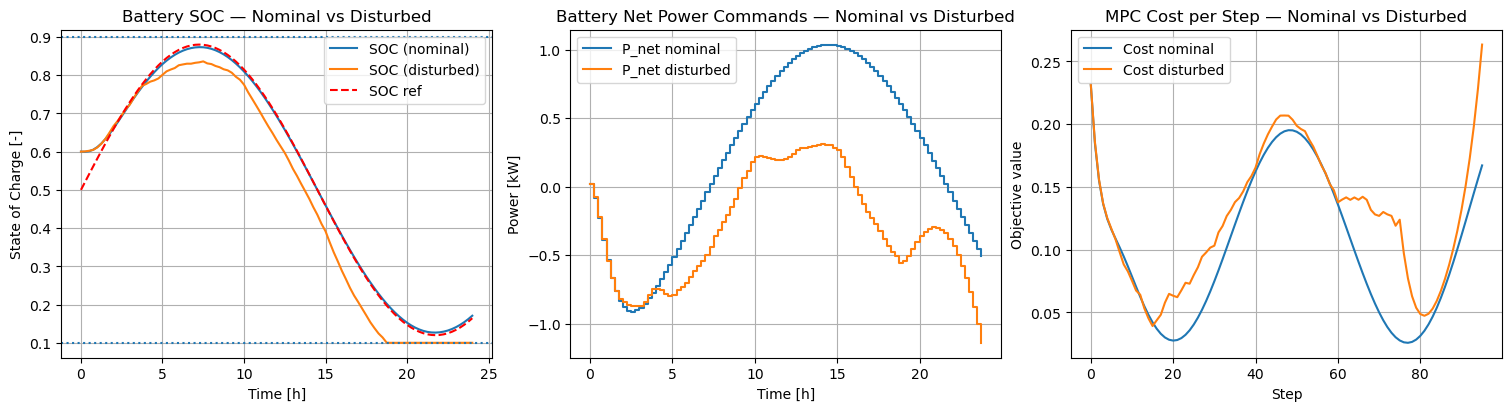

In [25]:
time_h = np.arange(T_sim+1)*dt_h
ref_to_plot = SOC_ref_profile[:T_sim+1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# --- Subplot 1: SOC ---
ax = axes[0]
ax.plot(time_h, res_nom["soc"], label="SOC (nominal)")
ax.plot(time_h, res_dis["soc"], label="SOC (disturbed)")
ax.plot(time_h, ref_to_plot, linestyle="--", label="SOC ref", color='r')
ax.axhline(SOC_min, linestyle=":") #, label="SOC min"
ax.axhline(SOC_max, linestyle=":") #, label="SOC max"
ax.set_xlabel("Time [h]")
ax.set_ylabel("State of Charge [-]")
ax.set_title("Battery SOC — Nominal vs Disturbed")
ax.legend()
ax.grid(True)

# --- Subplot 2: Power ---
ax = axes[1]
ax.step(time_h[:-1], res_nom["pnet"], where="post", label="P_net nominal")
ax.step(time_h[:-1], res_dis["pnet"], where="post", label="P_net disturbed")
ax.set_xlabel("Time [h]")
ax.set_ylabel("Power [kW]")
ax.set_title("Battery Net Power Commands — Nominal vs Disturbed")
ax.legend()
ax.grid(True)

# --- Subplot 3: Cost ---
ax = axes[2]
ax.plot(np.arange(T_sim), res_nom["J"], label="Cost nominal")
ax.plot(np.arange(T_sim), res_dis["J"], label="Cost disturbed")
ax.set_xlabel("Step")
ax.set_ylabel("Objective value")
ax.set_title("MPC Cost per Step — Nominal vs Disturbed")
ax.legend()
ax.grid(True)

plt.show()


## Robust Tube-based MPC

In the tube formulation you optimize a nominal problem with a charge-positive input $u_k = P^{ch}_k - P^{dis}_k$ and a simplified linear model $x_{k+1}=x_k +b u_k$. 

* Optimize a _nominal_ trajectory $(x^\star, u^\star)$ on **tightened constraints** and apply $u = u^\star + K\,(x^{\text{true}} - x^\star)$ with a fixed stabilizing gain $K$ (ancillary feedback). Where $e= x^{true} - x^*$ is the error.

* Tightening uses an **RPI$^1$ tube** $Z=[-z,+z]$ with radius $z = \bar w /(1 - |A + BK|)$ (scalar case, $A=1$), where $\bar w$ is the worst-case step disturbance in SoC units.

  Tightened sets:  
  $X_{\text{tight}} = [x_{\min}+z,\; x_{\max}-z]$,  
  $U_{\text{tight}} = [u_{\min}+|K|z,\; u_{\max}-|K|z]$.

Important consideration: 

* Nominal optimizer ensures $x^*\in X⊖Z$ and $u^*\in U⊖KZ$. Then the applied pair $(x,u)$ stays in the original constraints $X,U$ for any disturbance $|w_k|\le \bar{w}$.


#### Remarks
$^1$ A robust positive invariant (RPI) set is a region in a dynamic system's state space such that if a system's state starts within this set, its future states will always remain within the set, even in the presence of disturbances. 
<br> $^2$ Increase alpha toward 1.0 for weaker feedback (i.e. small K) &#8594; larger tube &#8594; More conservative &#8594; may lead to slow response or infeasibility.

#### Resourches:
J. B. Rawlings, D. Q. Mayne, and M. M. Diehl, _Model Predictive Control: Theory, Computation, and Design_, Nob Hill Publishing, Santa Barbara, CA, 2nd, paperback edition, 2020
<br>D.Q. Mayne, M.M. Seron and S.V. Raković, _Robust model predictive control of constrained linear systems with bounded disturbances_, Automatica, 41, 2, 2005

In [26]:
# Robust design knobs
Pbar   = 2.0   # [kW] we imagine a bounded parasitic load (this is the max value)
alpha  = 0.3   # closed-loop pole for ancillary feedback (|alpha|<1).

# Nominal linear model (charge-positive input)
eta_eff = min(eta_c, 1.0/eta_d)          # conservative single efficiency
b       = dt_h/E_kWh * eta_eff           # x+ = x + b*u_charge
# Input bounds for u_charge = Pch - Pdis  (charge-positive)
Umin, Umax = -P_dis_max, P_ch_max

# Disturbance bound (in SoC units) and tube radius
wbar = dt_h/E_kWh * Pbar                 # worst-case step disturbance in SoC units
K    = (alpha - 1.0)/b                   # so that (1 + bK) = alpha
z    = wbar / (1.0 - abs(alpha))

# Tightened sets for the *nominal* optimizer
Xlow_tight = SOC_min + z
Xup_tight  = SOC_max - z
Umin_tight = Umin + abs(K)*z
Umax_tight = Umax - abs(K)*z

assert Xlow_tight < Xup_tight, "Tightening too aggressive: state set empty. Reduce Pbar or change alpha."
assert Umin_tight < Umax_tight, "Tightening too aggressive: input set empty. Reduce Pbar or change alpha."

# Map charge-positive u to (Pch, Pdis)
def rb_split_to_charge_discharge(u_charge):
    Pch  = np.clip(u_charge, 0.0, P_ch_max) # positive charging
    Pdis = np.clip(-u_charge, 0.0, P_dis_max) # negative for discharging
    return Pch, Pdis

def rb_plant_step(x, u_charge, P_dist, w_soc=0.0):
    Pch, Pdis = rb_split_to_charge_discharge(u_charge)
    xnext = x + dt_h/E_kWh*(eta_c*Pch - (1.0/eta_d)*Pdis) - dt_h/E_kWh*P_dist + w_soc
    return float(np.clip(xnext, SOC_min, SOC_max)), Pch, Pdis

### Cost function
Differences vs the non-robust cost:
* There’s no $P^{ch}$, $P^{dis}$ inside the optimizer—just one input $u$. (The physical split $P^{ch}=max(u,0)$, $P^{dis}=max(-u,0)$ happens in the plant when we apply control.)
* No separate anti-simultaneity term is needed because a single $u$ can’t “charge and discharge at once.”
* Everything is evaluated on the nominal trajectory subject to tightened constraints; the ancillary feedback handles disturbances outside the optimizer.

In [27]:
def rb_build_nominal_tight_mpc(N):
    opti = ca.Opti()
    x = opti.variable(N+1)      # nominal SoC
    u = opti.variable(N)        # nominal u_charge (kW)

    x0_p    = opti.parameter()
    xref_p  = opti.parameter(N+1)
    uprev_p = opti.parameter()

    # Nominal linear dynamics (charge-positive)
    for k in range(N):
        opti.subject_to(x[k+1] == x[k] + b*u[k])

    # Tightened bounds
    opti.subject_to(x[0] == x0_p)
    opti.subject_to(opti.bounded(Xlow_tight, x, Xup_tight))
    opti.subject_to(opti.bounded(Umin_tight, u, Umax_tight))

    # Objective
    J  = w_soc_stage * ca.sumsqr(x[0:N] - xref_p[0:N])
    J += w_soc_term  * ca.sumsqr(x[N]   - xref_p[N])
    J += w_power * ca.sumsqr(u)           # regularize power
    J += w_slew * (u[0] - uprev_p)**2     # slew on u_charge
    if N > 1:
        J += w_slew * ca.sumsqr(u[1:] - u[:-1])

    opti.minimize(J)
    opti.solver("ipopt", {"print_time": False}, {"max_iter": 100, "print_level": 0})
    return opti, x, u, x0_p, xref_p, uprev_p

In [28]:
# Build robust controller
opti_t, x_t, u_t, x0p_t, xrefp_t, uprevp_t = rb_build_nominal_tight_mpc(N)

In [29]:
def run_constraint_tightening_mpc(T_sim):
    """Tube MPC with u_charge input; plotted vs P_net with sign flip."""
    x_true = [SOC0]
    x_nom  = [float(np.clip(SOC0, Xlow_tight, Xup_tight))]
    u_nom_hist, u_appl_hist = [], []
    pch_hist, pdis_hist = [], []
    J_hist = []
    uprev  = 0.0

    # Disturbance (clip to design bound)
    P_dist, w_soc_vec = make_disturbance_profile(T_sim, dt_h)
    P_dist = np.clip(P_dist, -Pbar, Pbar)

    for t in range(T_sim):
        xref = SOC_ref_profile[t:t+N+1]

        # Nominal problem on tightened sets
        opti_t.set_value(x0p_t, x_nom[-1])
        opti_t.set_value(xrefp_t, xref)
        opti_t.set_value(uprevp_t, uprev)
        opti_t.set_initial(x_t, np.linspace(x_nom[-1], xref[-1], N+1))
        opti_t.set_initial(u_t, 0.0)

        try:
            sol   = opti_t.solve()
            u_nom = float(sol.value(u_t[0]))   # charge-positive
            Jk    = float(sol.value(opti_t.f))
            opti_t.set_initial(opti_t.x, opti_t.value(opti_t.x))
        except RuntimeError:
            u_nom, Jk = 0.0, np.nan
            opti_t.set_initial(opti_t.x, opti_t.value(opti_t.x))

        # Ancillary feedback (tube): u_app = u_nom + K*(x_true - x_nom)
        e     = x_true[-1] - x_nom[-1]
        u_app = float(np.clip(u_nom + K*e, Umin, Umax))  # charge-positive; saturate to real bounds

        # Plant step (real split model)
        xnext, Pch, Pdis = rb_plant_step(x_true[-1], u_app, P_dist[t], w_soc=w_soc_vec[t])

        # Advance nominal model (and keep inside tightened set)
        x_nom_next = float(np.clip(x_nom[-1] + b*u_nom, Xlow_tight, Xup_tight))

        # Log
        x_true.append(xnext); x_nom.append(x_nom_next)
        u_nom_hist.append(u_nom); u_appl_hist.append(u_app)
        pch_hist.append(Pch); pdis_hist.append(Pdis); J_hist.append(Jk)
        uprev = u_nom

    # Convert charge-positive u to discharge-positive P_net for comparison:
    pnet_nom_equiv = -np.array(u_nom_hist)  # since P_net = Pdis - Pch = -(Pch - Pdis)
    pnet_equiv     = -np.array(u_appl_hist)

    return {
        "soc_true": np.array(x_true),
        "soc_nom":  np.array(x_nom),
        "u_nom":    np.array(u_nom_hist),          # charge-positive (for reference)
        "u":        np.array(u_appl_hist),         # charge-positive (applied)
        "pnet_nom": pnet_nom_equiv,                # discharge-positive (comparable to res_*["pnet"])
        "pnet":     pnet_equiv,                    # discharge-positive (applied)
        "J":        np.array(J_hist),
        "Pbar":     Pbar, "alpha": alpha, "z": z,
        "tight_X":  (Xlow_tight, Xup_tight),
        "tight_U":  (Umin_tight, Umax_tight),
        "Pdist":    P_dist,                        
        "corr_u":   np.array(u_appl_hist)-np.array(u_nom_hist),
    }

In [30]:
# Run robust controller
res_rob = run_constraint_tightening_mpc(T_sim)

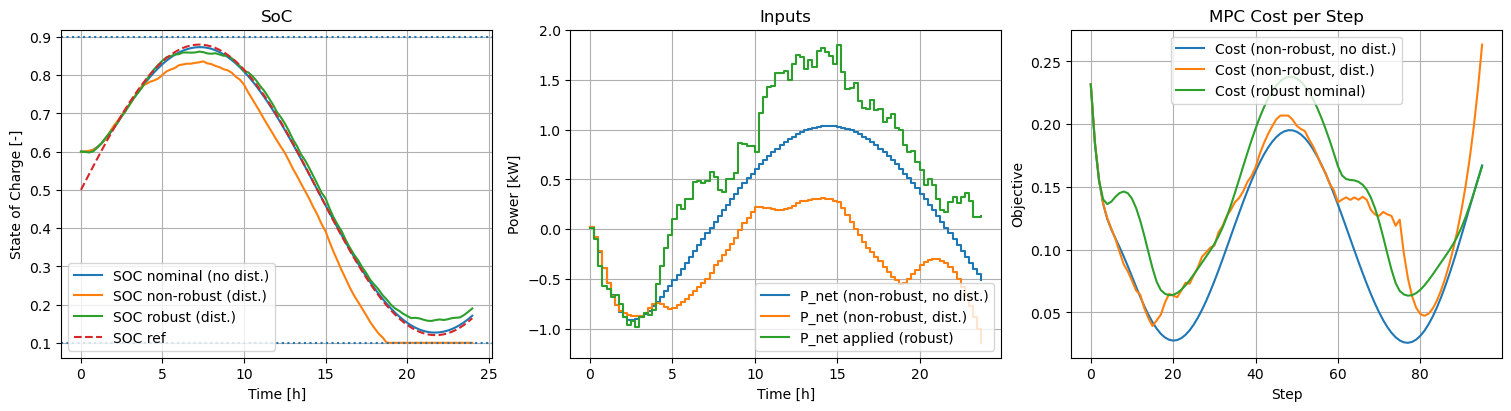

Tube radius z = 0.0529 (from Pbar=2.0 kW, alpha=0.3).
Tightened SoC: [0.153, 0.847] | Tightened u_charge: [-2.895, 2.895]


In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

# 1) SoC
ax = axes[0]
ax.plot(time_h, res_nom["soc"], label="SOC nominal (no dist.)")
ax.plot(time_h, res_dis["soc"], label="SOC non-robust (dist.)")
ax.plot(time_h, res_rob["soc_true"], label="SOC robust (dist.)")
ax.plot(time_h, ref_to_plot, linestyle="--", label="SOC ref")
ax.axhline(SOC_min, linestyle=":") #, label="SOC min"
ax.axhline(SOC_max, linestyle=":") #, label="SOC max"
ax.set_xlabel("Time [h]"); ax.set_ylabel("State of Charge [-]")
ax.set_title("SoC")
ax.legend(); ax.grid(True)

# 2) Net power (ALL discharge-positive)
ax = axes[1]
ax.step(time_h[:-1], res_nom["pnet"], where="post", label="P_net (non-robust, no dist.)")
ax.step(time_h[:-1], res_dis["pnet"], where="post", label="P_net (non-robust, dist.)")
#ax.step(time_h[:-1], res_rob["pnet_nom"], where="post", label="P_net nominal (robust)")
ax.step(time_h[:-1], res_rob["pnet"], where="post", label="P_net applied (robust)")
ax.set_xlabel("Time [h]"); ax.set_ylabel("Power [kW]")
ax.set_title("Inputs")
ax.legend(); ax.grid(True)

# 3) Objective values
ax = axes[2]
ax.plot(np.arange(T_sim), res_nom["J"], label="Cost (non-robust, no dist.)")
ax.plot(np.arange(T_sim), res_dis["J"], label="Cost (non-robust, dist.)")
ax.plot(np.arange(T_sim), res_rob["J"], label="Cost (robust nominal)")
ax.set_xlabel("Step"); ax.set_ylabel("Objective")
ax.set_title("MPC Cost per Step")
ax.legend(); ax.grid(True)

plt.show()

print(f"Tube radius z = {z:.4f} (from Pbar={Pbar} kW, alpha={alpha}).")
print(f"Tightened SoC: [{Xlow_tight:.3f}, {Xup_tight:.3f}] | Tightened u_charge: [{Umin_tight:.3f}, {Umax_tight:.3f}]")
#print("Note: robust traces are converted to discharge-positive P_net for plotting (pnet = -u_charge).")

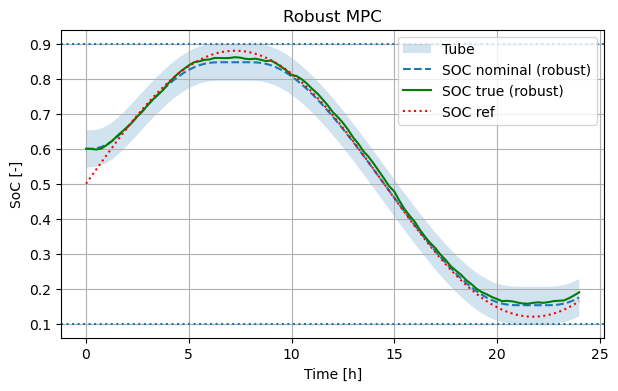

In [32]:
# Trim to the shortest length to avoid shape mismatches
n = min(len(time_h), len(res_rob["soc_nom"]), len(res_rob["soc_true"]), len(ref_to_plot))
t         = time_h[:n]
soc_nom   = res_rob["soc_nom"][:n]
soc_true  = res_rob["soc_true"][:n]
ref       = ref_to_plot[:n]
z         = float(res_rob.get("z", 0.0))  # tube radius

plt.figure(figsize=(7, 4))
plt.fill_between(t, soc_nom - z, soc_nom + z, alpha=0.2, label="Tube")
plt.plot(t, soc_nom, linestyle="--", label="SOC nominal (robust)")
plt.plot(t, soc_true, label="SOC true (robust)", color='g')
plt.plot(t, ref, linestyle=":", label="SOC ref", color='r')
plt.axhline(SOC_min, linestyle=":") #, label="SOC min"
plt.axhline(SOC_max, linestyle=":") #, label="SOC max"
plt.xlabel("Time [h]")
plt.ylabel("SoC [-]")
plt.title("Robust MPC")
plt.grid(True)
plt.legend()
plt.show()

## Error Distribution

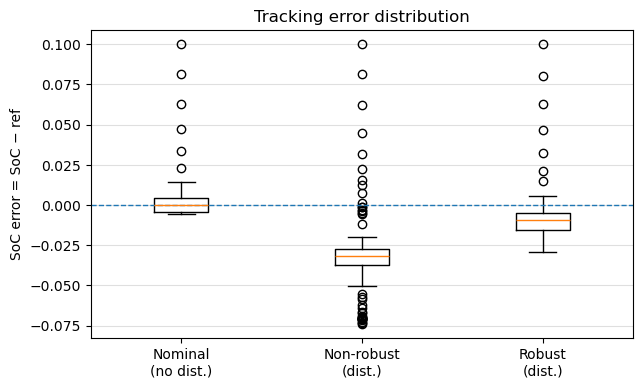

                  | MAE    | RMSE
Nominal (no dist.)| 0.0072 | 0.0164
Nominal (dist.)   | 0.0380 | 0.0431
Robust (dist.)    | 0.0149 | 0.0208


In [17]:
n = min(len(ref_to_plot),
        len(res_nom["soc"]),
        len(res_dis["soc"]),
        len(res_rob["soc_true"])) 

ref   = ref_to_plot[:n]
#e_nom = np.abs(res_nom["soc"][:n] - ref)
e_nom = res_nom["soc"][:n]      - ref
e_dis = res_dis["soc"][:n]      - ref
e_rob = res_rob["soc_true"][:n] - ref   # robust (disturbed)

plt.figure(figsize=(7, 4))
plt.boxplot(
    [e_nom, e_dis, e_rob],
    tick_labels=["Nominal\n(no dist.)", "Non-robust\n(dist.)", "Robust\n(dist.)"],
    showmeans=False,
    meanline=True
)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("SoC error = SoC − ref")
plt.title("Tracking error distribution")
plt.grid(axis="y", alpha=0.4)
plt.show()

def mae(x):  return np.mean(np.abs(x))
def rmse(x): return np.sqrt(np.mean(x**2))

print("                  | MAE    | RMSE")
print(f"Nominal (no dist.)| {mae(e_nom):.4f} | {rmse(e_nom):.4f}")
print(f"Nominal (dist.)   | {mae(e_dis):.4f} | {rmse(e_dis):.4f}")
print(f"Robust (dist.)    | {mae(e_rob):.4f} | {rmse(e_rob):.4f}")

## Plot 

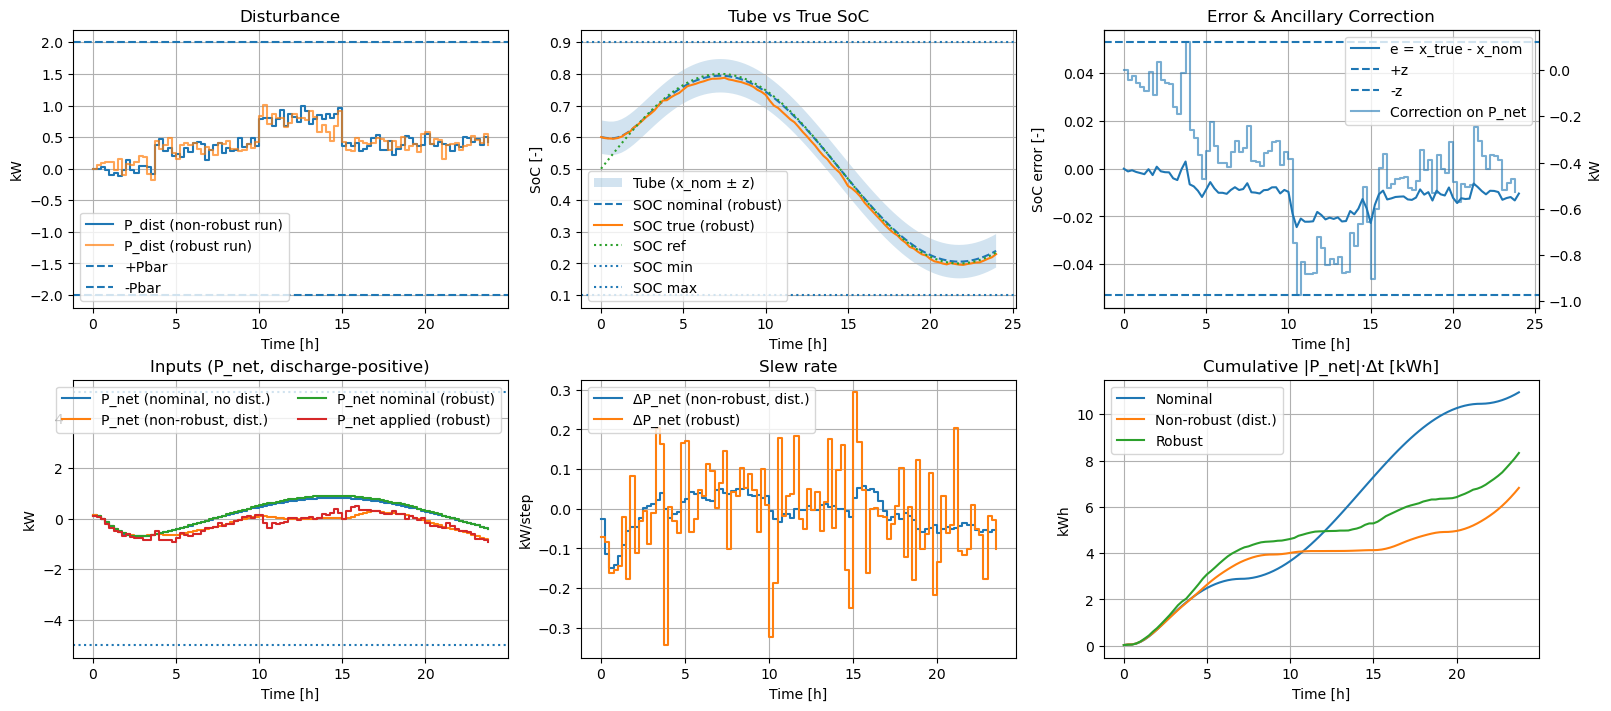

In [18]:
# convenience
t   = time_h
tk  = np.arange(T_sim)

# 1) Disturbance + bound
# 2) Tube view (x_nom ± z) vs true SoC
# 3) Error and tube radius
# 4) Inputs (discharge-positive P_net)
# 5) Input slew (kW/step)
# 6) Cumulative energy throughput (kWh)

fig, axes = plt.subplots(2, 3, figsize=(16, 7), constrained_layout=True)

# --- (1) Disturbance profile ---
ax = axes[0,0]
if "Pdist" in res_dis:
    ax.step(t[:-1], res_dis["Pdist"], where="post", label="P_dist (non-robust run)")
if "Pdist" in res_rob:
    ax.step(t[:-1], res_rob["Pdist"], where="post", label="P_dist (robust run)", alpha=0.7)
    if "Pbar" in res_rob:
        ax.axhline(res_rob["Pbar"], linestyle="--", label="+Pbar")
        ax.axhline(-res_rob["Pbar"], linestyle="--", label="-Pbar")
ax.set_title("Disturbance")
ax.set_xlabel("Time [h]"); ax.set_ylabel("kW")
ax.grid(True); ax.legend()

# --- (2) Tube vs true/nominal SoC (robust) ---
ax = axes[0,1]
if "soc_nom" in res_rob:
    z = res_rob.get("z", 0.0)
    ax.fill_between(t, res_rob["soc_nom"]-z, res_rob["soc_nom"]+z, alpha=0.2, label="Tube (x_nom ± z)")
    ax.plot(t, res_rob["soc_nom"], linestyle="--", label="SOC nominal (robust)")
    ax.plot(t, res_rob["soc_true"], label="SOC true (robust)")
ax.plot(t, ref_to_plot, linestyle=":", label="SOC ref")
ax.axhline(SOC_min, linestyle=":", label="SOC min")
ax.axhline(SOC_max, linestyle=":", label="SOC max")
ax.set_title("Tube vs True SoC")
ax.set_xlabel("Time [h]"); ax.set_ylabel("SoC [-]")
ax.grid(True); ax.legend()

# --- (3) Error & correction (robust) ---
ax = axes[0,2]
if "soc_nom" in res_rob:
    e = res_rob["soc_true"] - res_rob["soc_nom"]
    z = res_rob.get("z", 0.0)
    ax.plot(t, e, label="e = x_true - x_nom")
    ax.axhline(+z, linestyle="--", label="+z")
    ax.axhline(-z, linestyle="--", label="-z")
ax2 = ax.twinx()
if "corr_u" in res_rob:
    ax2.step(t[:-1], -res_rob["corr_u"], where="post", alpha=0.6, label="Correction on P_net")  # flip sign for P_net
ax.set_title("Error & Ancillary Correction")
ax.set_xlabel("Time [h]"); ax.set_ylabel("SoC error [-]")
ax2.set_ylabel("kW")
ax.grid(True)
# combined legend
h1,l1 = ax.get_legend_handles_labels()
h2,l2 = ax2.get_legend_handles_labels()
ax.legend(h1+h2,l1+l2, loc="upper right")

# --- (4) Inputs (all discharge-positive) ---
ax = axes[1,0]
ax.step(t[:-1], res_nom["pnet"], where="post", label="P_net (nominal, no dist.)")
ax.step(t[:-1], res_dis["pnet"], where="post", label="P_net (non-robust, dist.)")
if "pnet" in res_rob:
    ax.step(t[:-1], res_rob["pnet_nom"], where="post", label="P_net nominal (robust)")
    ax.step(t[:-1], res_rob["pnet"], where="post", label="P_net applied (robust)")
ax.axhline(P_dis_max, linestyle=":") #, label="Discharge max"
ax.axhline(-P_ch_max, linestyle=":") #, label="Charge max"
ax.set_title("Inputs (P_net, discharge-positive)")
ax.set_xlabel("Time [h]"); ax.set_ylabel("kW")
ax.grid(True); ax.legend(ncol=2)

# --- (5) Input slew (kW per step) ---
ax = axes[1,1]
ax.step(t[:-2], np.diff(res_dis["pnet"]), where="post", label="ΔP_net (non-robust, dist.)")
if "pnet" in res_rob:
    ax.step(t[:-2], np.diff(res_rob["pnet"]), where="post", label="ΔP_net (robust)")
ax.set_title("Slew rate")
ax.set_xlabel("Time [h]"); ax.set_ylabel("kW/step")
ax.grid(True); ax.legend()

# --- (6) Cumulative energy throughput (wear proxy) ---
ax = axes[1,2]
through_nom = np.cumsum(np.abs(res_nom["pnet"])) * dt_h
through_dis = np.cumsum(np.abs(res_dis["pnet"])) * dt_h
ax.plot(t[:-1], through_nom, label="Nominal")
ax.plot(t[:-1], through_dis, label="Non-robust (dist.)")
if "pnet" in res_rob:
    through_rob = np.cumsum(np.abs(res_rob["pnet"])) * dt_h
    ax.plot(t[:-1], through_rob, label="Robust")
ax.set_title("Cumulative |P_net|·Δt [kWh]")
ax.set_xlabel("Time [h]"); ax.set_ylabel("kWh")
ax.grid(True); ax.legend()

plt.show()
